## Task 1 : Data Collection & Dataset Understanding
### Goal:
- Collect or load a dataset and understand its structure.
Key Requirements:
- Identify columns and data types
- Understand dataset size and features
- Describe what the data represents
### Key Skills:
- Data understanding, exploratory thinking

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [2]:
# Load datasets
data2015 = pd.read_csv("2015.csv")
data2016 = pd.read_csv("2016.csv")
data2017 = pd.read_csv("2017.csv")
data2018 = pd.read_csv("2018.csv")
data2019 = pd.read_csv("2019.csv")

In [3]:
data2015.head()

,Country,Region,Happiness Rank,Happiness Score,Standard Error,Economy (GDP per Capita),Family,Health (Life Expectancy),Freedom,Trust (Government Corruption),Generosity,Dystopia Residual
0,Switzerland,Western Europe,1,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2.51738
1,Iceland,Western Europe,2,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2.70201
2,Denmark,Western Europe,3,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2.49204
3,Norway,Western Europe,4,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2.46531
4,Canada,North America,5,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2.45176


In [4]:
data2015.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        158 non-null    object 
 1   Region                         158 non-null    object 
 2   Happiness Rank                 158 non-null    int64  
 3   Happiness Score                158 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   Economy (GDP per Capita)       158 non-null    float64
 6   Family                         158 non-null    float64
 7   Health (Life Expectancy)       158 non-null    float64
 8   Freedom                        158 non-null    float64
 9   Trust (Government Corruption)  158 non-null    float64
 10  Generosity                     158 non-null    float64
 11  Dystopia Residual              158 non-null    float64
dtypes: float64(9), int64(1), object(2)
memory usage: 1

In [5]:
data2015.shape, data2016.shape, data2017.shape, data2018.shape, data2019.shape

((158, 12), (157, 13), (155, 12), (156, 9), (156, 9))

## Task 2: Data Cleaning & Preprocessing
### Goal:
- Prepare the dataset for analysis by cleaning and organizing data.
### Key Requirements:
- Handle missing values.
- Remove duplicates.
- Format data correctly.
### Key Skills:
- Data preprocessing, data quality management.

In [6]:
# Add year column
data2015["Year"] = 2015
data2016["Year"] = 2016
data2017["Year"] = 2017
data2018["Year"] = 2018
data2019["Year"] = 2019

In [7]:
def standardize_columns(data):
    rename_dict = {
        'Country': 'Country',
        'Country or region': 'Country',
        'Happiness Rank': 'Rank',
        'Overall rank': 'Rank',
        'Happiness Score': 'Happiness_Score',
        'Score': 'Happiness_Score',
        'Economy (GDP per Capita)': 'GDP',
        'GDP per capita': 'GDP',
        'Health (Life Expectancy)': 'Life_Expectancy',
        'Healthy life expectancy': 'Life_Expectancy',
        'Family': 'Social_Support',
        'Social support': 'Social_Support',
        'Freedom': 'Freedom',
        'Freedom to make life choices': 'Freedom',
        'Trust (Government Corruption)': 'Corruption',
        'Perceptions of corruption': 'Corruption',
        'Generosity': 'Generosity',
        'Region': 'Region'
    }

    data = data.rename(columns=rename_dict)
    return data

# Apply standardization
data2015 = standardize_columns(data2015)
data2016 = standardize_columns(data2016)
data2017 = standardize_columns(data2017)
data2018 = standardize_columns(data2018)
data2019 = standardize_columns(data2019)

# Combine all datasets
combined_data = pd.concat([data2015, data2016, data2017, data2018, data2019],ignore_index=True)

In [8]:
combined_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        782 non-null    object 
 1   Region                         315 non-null    object 
 2   Rank                           627 non-null    float64
 3   Happiness_Score                627 non-null    float64
 4   Standard Error                 158 non-null    float64
 5   GDP                            627 non-null    float64
 6   Social_Support                 782 non-null    float64
 7   Life_Expectancy                627 non-null    float64
 8   Freedom                        782 non-null    float64
 9   Corruption                     626 non-null    float64
 10  Generosity                     782 non-null    float64
 11  Dystopia Residual              315 non-null    float64
 12  Year                           782 non-null    int

In [9]:
combined_data.shape

(782, 23)

In [10]:
combined_data.columns

Index(['Country', 'Region', 'Rank', 'Happiness_Score', 'Standard Error', 'GDP',
       'Social_Support', 'Life_Expectancy', 'Freedom', 'Corruption',
       'Generosity', 'Dystopia Residual', 'Year', 'Lower Confidence Interval',
       'Upper Confidence Interval', 'Happiness.Rank', 'Happiness.Score',
       'Whisker.high', 'Whisker.low', 'Economy..GDP.per.Capita.',
       'Health..Life.Expectancy.', 'Trust..Government.Corruption.',
       'Dystopia.Residual'],
      dtype='object')

In [11]:
combined_data.isnull().sum()

Country                            0
Region                           467
Rank                             155
Happiness_Score                  155
Standard Error                   624
GDP                              155
Social_Support                     0
Life_Expectancy                  155
Freedom                            0
Corruption                       156
Generosity                         0
Dystopia Residual                467
Year                               0
Lower Confidence Interval        625
Upper Confidence Interval        625
Happiness.Rank                   627
Happiness.Score                  627
Whisker.high                     627
Whisker.low                      627
Economy..GDP.per.Capita.         627
Health..Life.Expectancy.         627
Trust..Government.Corruption.    627
Dystopia.Residual                627
dtype: int64

In [12]:
combined_data.duplicated().sum()

0

In [13]:
numerical_columns = combined_data.select_dtypes(include='number').columns
categorical_columns = combined_data.select_dtypes(include='object').columns

In [14]:
# Handle missing values
# Fill numeric columns with median
for col in numerical_columns:
    combined_data[col] = combined_data[col].fillna(combined_data[col].median())

# Fill categorical columns
for col in categorical_columns:
    combined_data[col] = combined_data[col].fillna("Unknown")

In [15]:
combined_data.isnull().sum()

Country                          0
Region                           0
Rank                             0
Happiness_Score                  0
Standard Error                   0
GDP                              0
Social_Support                   0
Life_Expectancy                  0
Freedom                          0
Corruption                       0
Generosity                       0
Dystopia Residual                0
Year                             0
Lower Confidence Interval        0
Upper Confidence Interval        0
Happiness.Rank                   0
Happiness.Score                  0
Whisker.high                     0
Whisker.low                      0
Economy..GDP.per.Capita.         0
Health..Life.Expectancy.         0
Trust..Government.Corruption.    0
Dystopia.Residual                0
dtype: int64

## Task 3: Exploratory Data Analysis (EDA)
### Goal:
- Analyze the dataset to discover patterns and trends.
### Key Requirements:
- Calculate basic statistics.
- Identify trends and outliers.
- Summarize findings.
### Key Skills:
- Statistical thinking, data analysis.

In [16]:
combined_data.describe()

,Rank,Happiness_Score,Standard Error,GDP,Social_Support,Life_Expectancy,Freedom,Corruption,Generosity,Dystopia Residual,...,Lower Confidence Interval,Upper Confidence Interval,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Health..Life.Expectancy.,Trust..Government.Corruption.,Dystopia.Residual
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,...,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,78.896419,5.376041,0.044737,0.911148,1.078392,0.635788,0.411091,0.119204,0.218576,2.211571,...,5.246114,5.431643,78.000000,5.293869,5.386343,5.205552,1.048749,0.595199,0.096442,1.836344
std,40.546343,1.009461,0.007849,0.361158,0.329548,0.223448,0.152880,0.096590,0.122321,0.354275,...,0.513414,0.508557,19.932986,0.503217,0.497775,0.509066,0.189550,0.107510,0.047053,0.222147
min,1.000000,2.839000,0.018480,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.328580,...,2.732000,3.078000,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.377914
25%,49.250000,4.697000,0.043940,0.706490,0.869363,0.535250,0.309768,0.063260,0.130000,2.211260,...,5.237000,5.419000,78.000000,5.279000,5.370032,5.193152,1.064578,0.606042,0.089848,1.832910
50%,79.000000,5.339000,0.043940,0.960000,1.124735,0.669260,0.431000,0.091895,0.201982,2.211260,...,5.237000,5.419000,78.000000,5.279000,5.370032,5.193152,1.064578,0.606042,0.089848,1.832910
75%,108.000000,5.976750,0.043940,1.151277,1.327250,0.786672,0.531000,0.137527,0.278832,2.211260,...,5.237000,5.419000,78.000000,5.279000,5.370032,5.193152,1.064578,0.606042,0.089848,1.832910
max,158.000000,7.769000,0.136930,2.096000,1.644000,1.141000,0.724000,0.551910,0.838075,3.837720,...,7.460000,7.669000,155.000000,7.537000,7.622030,7.479556,1.870766,0.949492,0.464308,3.117485


In [17]:
# Identify outliers 
z_scores = np.abs(zscore(combined_data[numerical_columns]))
outliers = (z_scores > 3).sum(axis=0)
print("Outliers per column:\n", outliers)
outlier_percentage = outliers.sum() / len(combined_data) * 100
print(f"Percentage of outliers: {outlier_percentage:.2f}%")

Outliers per column:
 Rank                              0
Happiness_Score                   0
Standard Error                   19
GDP                               1
Social_Support                    5
Life_Expectancy                   0
Freedom                           0
Corruption                       20
Generosity                        6
Dystopia Residual                20
Year                              0
Lower Confidence Interval        35
Upper Confidence Interval        33
Happiness.Rank                   36
Happiness.Score                  32
Whisker.high                     33
Whisker.low                      34
Economy..GDP.per.Capita.         31
Health..Life.Expectancy.         27
Trust..Government.Corruption.    25
Dystopia.Residual                30
dtype: int64
Percentage of outliers: 49.49%


In [18]:
# DOES GDP CORRELATE WITH HAPPINESS?
correlation = combined_data["GDP"].corr(combined_data["Happiness_Score"])
print("GDP vs Happiness Correlation:", correlation)

GDP vs Happiness Correlation: 0.785031065463647


In [19]:
# WHICH FACTORS MATTER MOST?
# Correlation matrix
important_features = ['Happiness_Score','GDP','Social_Support','Life_Expectancy','Freedom','Generosity','Corruption']
corr_matrix = combined_data[important_features].corr()
corr_matrix

,Happiness_Score,GDP,Social_Support,Life_Expectancy,Freedom,Generosity,Corruption
Happiness_Score,1.000000,0.785031,0.578658,0.735145,0.492132,0.115175,0.388722
GDP,0.785031,1.000000,0.518500,0.795437,0.300885,-0.014753,0.281523
Social_Support,0.578658,0.518500,1.000000,0.559863,0.420361,-0.037262,0.075265
Life_Expectancy,0.735145,0.795437,0.559863,1.000000,0.305272,0.021493,0.230982
Freedom,0.492132,0.300885,0.420361,0.305272,1.000000,0.290706,0.402641
Generosity,0.115175,-0.014753,-0.037262,0.021493,0.290706,1.000000,0.267147
Corruption,0.388722,0.281523,0.075265,0.230982,0.402641,0.267147,1.000000


In [20]:
combined_data.head(3)

,Country,Region,Rank,Happiness_Score,Standard Error,GDP,Social_Support,Life_Expectancy,Freedom,Corruption,...,Lower Confidence Interval,Upper Confidence Interval,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Health..Life.Expectancy.,Trust..Government.Corruption.,Dystopia.Residual
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,5.237,5.419,78.0,5.279,5.370032,5.193152,1.064578,0.606042,0.089848,1.83291
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,5.237,5.419,78.0,5.279,5.370032,5.193152,1.064578,0.606042,0.089848,1.83291
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,5.237,5.419,78.0,5.279,5.370032,5.193152,1.064578,0.606042,0.089848,1.83291


## Task 4: Data Visualization 
### Goal:
- Create visual representations to communicate insights clearly.
### Key Requirements:
- Create charts and graphs.
- Choose appropriate visual types.
- Highlight key insights.
### Key Skills:
- Data visualization, storytelling with data

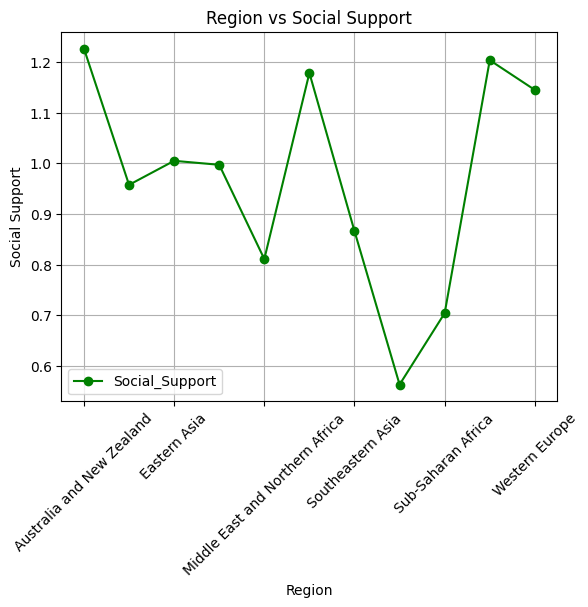

In [21]:
grouped_Region_by_Social_Support = combined_data.groupby("Region")["Social_Support"].mean().reset_index()
grouped_Region_by_Social_Support.plot(x="Region", y="Social_Support", kind="line", marker='o',color='green')
plt.title("Region vs Social Support")
plt.xlabel("Region")
plt.ylabel("Social Support")
plt.xticks(rotation=45)
plt.grid()
plt.show()

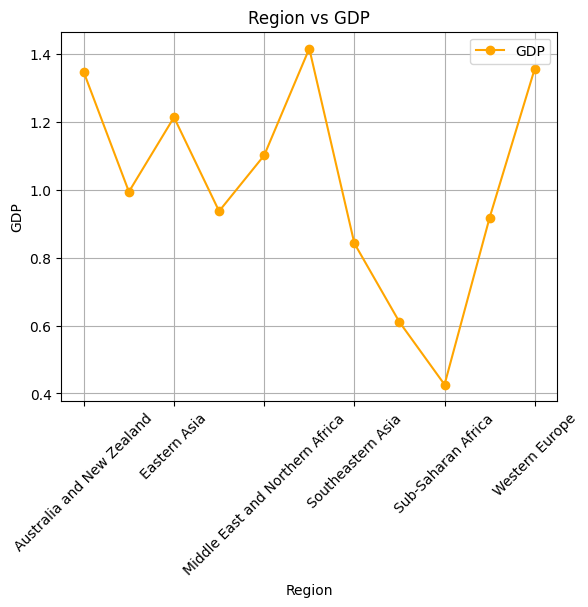

In [22]:
grouped_region_by_gdp = combined_data.groupby("Region")["GDP"].mean().reset_index()
grouped_region_by_gdp.plot(x="Region", y="GDP", kind="line", marker='o',color='orange')
plt.title("Region vs GDP")
plt.xlabel("Region")
plt.ylabel("GDP")
plt.xticks(rotation=45)
plt.grid()
plt.show()

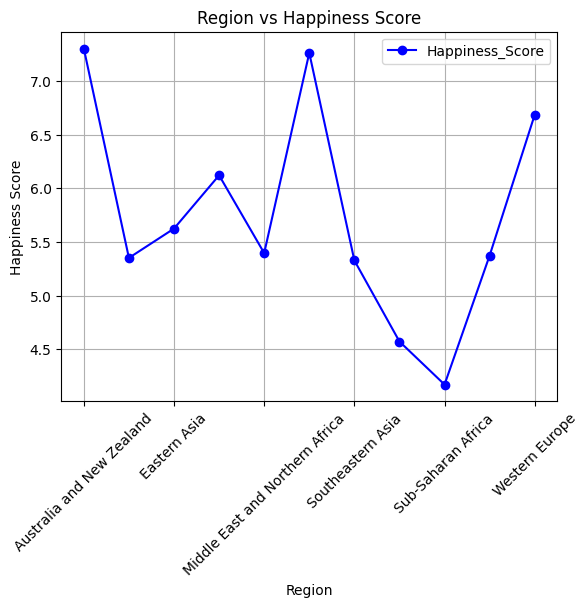

In [23]:
grouped_happiness_by_region = combined_data.groupby("Region")["Happiness_Score"].mean().reset_index()
grouped_happiness_by_region.plot(x="Region", y="Happiness_Score", kind="line", marker='o',color='blue')
plt.title("Region vs Happiness Score")
plt.xlabel("Region")
plt.ylabel("Happiness Score")
plt.xticks(rotation=45)
plt.grid()
plt.show()

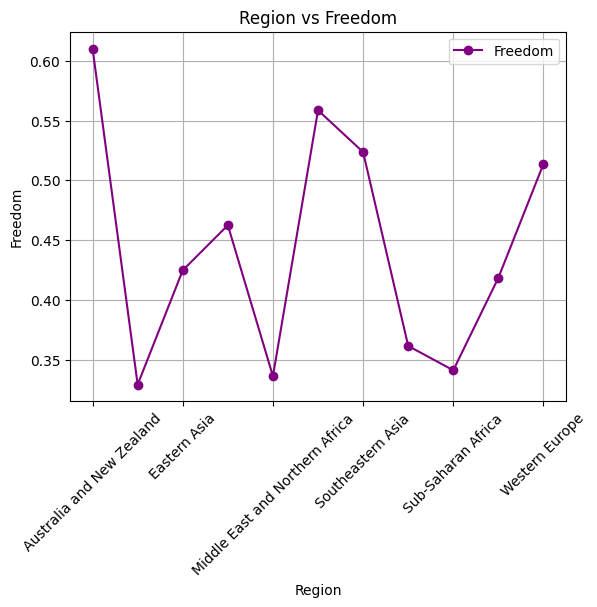

In [24]:
grouped_happiness_by_freedom = combined_data.groupby("Region")["Freedom"].mean().reset_index()
grouped_happiness_by_freedom.plot(x="Region", y="Freedom", kind="line", marker='o',color='purple')
plt.title("Region vs Freedom")
plt.xlabel("Region")
plt.ylabel("Freedom")
plt.xticks(rotation=45)
plt.grid()
plt.show()

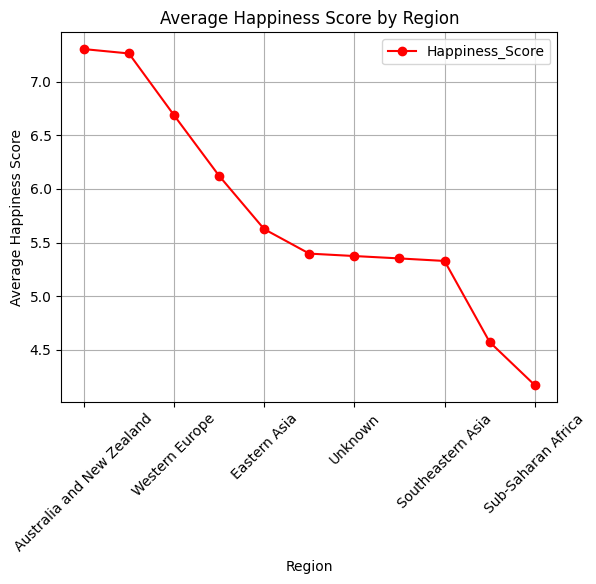

In [25]:
grouped_happiness_by_country = combined_data.groupby("Region")["Happiness_Score"].mean().reset_index()
grouped_happiness_by_country = grouped_happiness_by_country.sort_values(by="Happiness_Score", ascending=False)
grouped_happiness_by_country.plot(x="Region", y="Happiness_Score", kind="line", marker='o',color='red')
plt.title("Average Happiness Score by Region")
plt.xlabel("Region")
plt.ylabel("Average Happiness Score")
plt.xticks(rotation=45)
plt.grid()
plt.show()

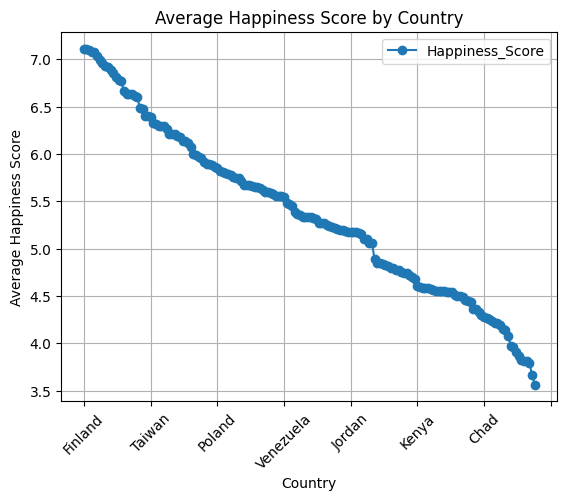

In [26]:
grouped_happiness_by_country = combined_data.groupby("Country")["Happiness_Score"].mean().reset_index()
grouped_happiness_by_country = grouped_happiness_by_country.sort_values(by="Happiness_Score", ascending=False)
grouped_happiness_by_country.head(10)
grouped_happiness_by_country.plot(x="Country", y="Happiness_Score", kind="line", marker='o')
plt.title("Average Happiness Score by Country")
plt.xlabel("Country")
plt.ylabel("Average Happiness Score")
plt.xticks(rotation=45)
plt.grid()
plt.show()

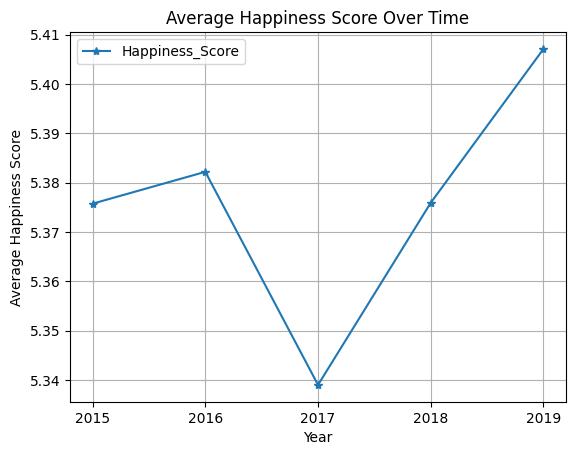

In [27]:
Grouped_happiness = combined_data.groupby("Year")["Happiness_Score"].mean().reset_index()
Grouped_happiness.plot(x="Year", y="Happiness_Score", kind="line", marker='*')
plt.title("Average Happiness Score Over Time")
plt.xlabel("Year")
plt.ylabel("Average Happiness Score")
plt.xticks(Grouped_happiness["Year"])
plt.grid()
plt.show()


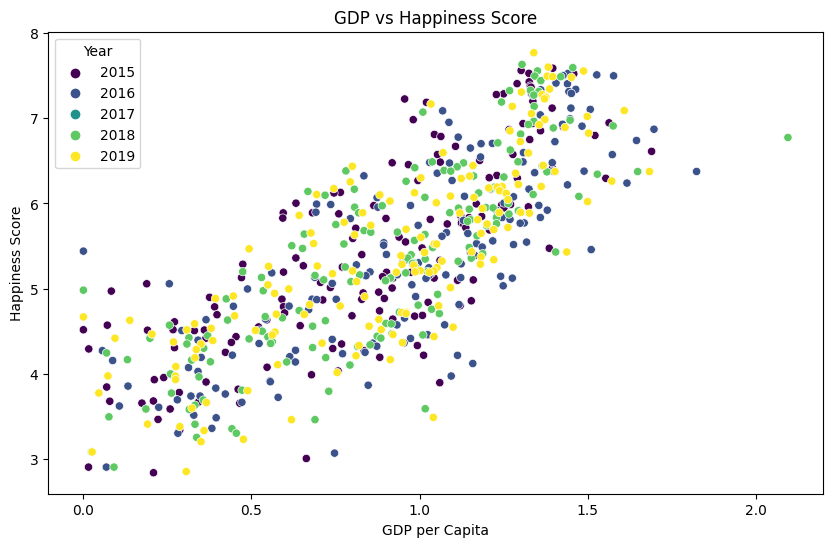

In [28]:
# Scatter plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=combined_data,x="GDP",y="Happiness_Score",hue="Year",palette="viridis")
plt.title("GDP vs Happiness Score")
plt.xlabel("GDP per Capita")
plt.ylabel("Happiness Score")
plt.show()

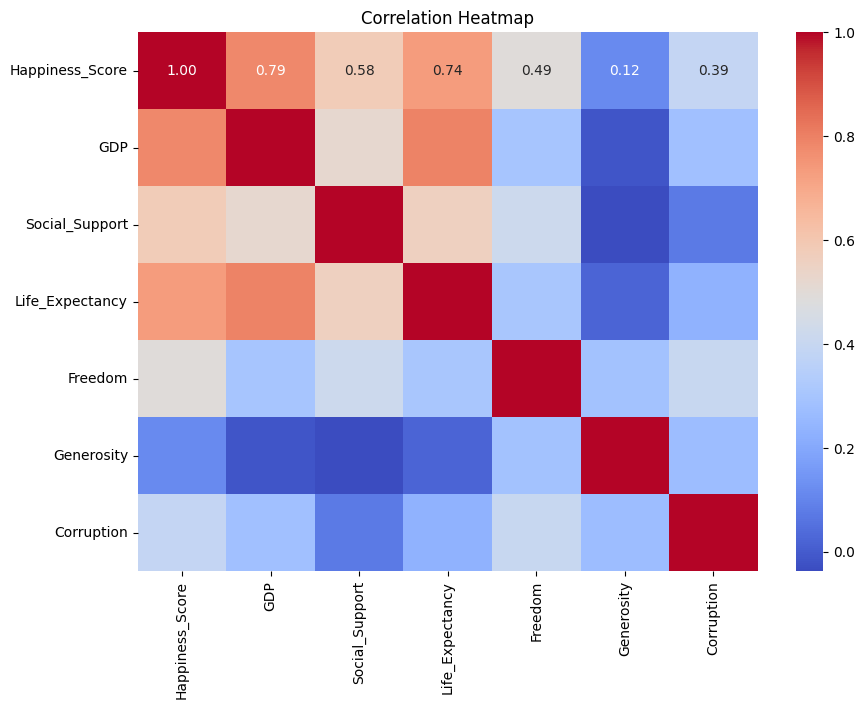

In [29]:
# Heatmap
plt.figure(figsize=(10,7))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

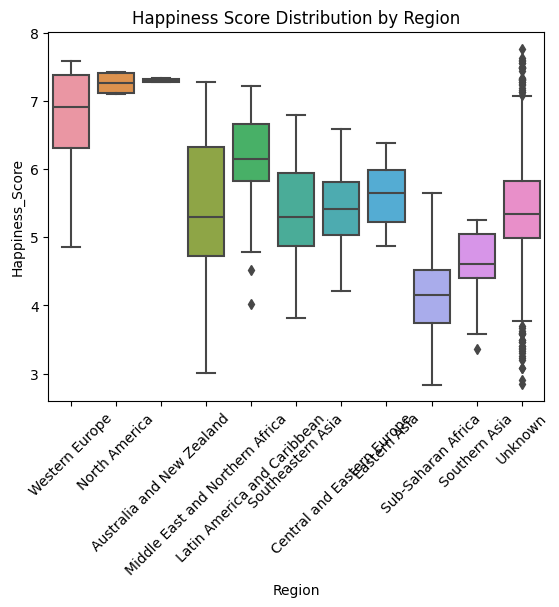

In [30]:
sns.boxplot(x='Region', y='Happiness_Score', data=combined_data)
plt.xticks(rotation=45)
plt.title('Happiness Score Distribution by Region')
plt.show()

In [31]:
combined_data.head()   

,Country,Region,Rank,Happiness_Score,Standard Error,GDP,Social_Support,Life_Expectancy,Freedom,Corruption,...,Lower Confidence Interval,Upper Confidence Interval,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Health..Life.Expectancy.,Trust..Government.Corruption.,Dystopia.Residual
0,Switzerland,Western Europe,1.0,7.587,0.03411,1.39651,1.34951,0.94143,0.66557,0.41978,...,5.237,5.419,78.0,5.279,5.370032,5.193152,1.064578,0.606042,0.089848,1.83291
1,Iceland,Western Europe,2.0,7.561,0.04884,1.30232,1.40223,0.94784,0.62877,0.14145,...,5.237,5.419,78.0,5.279,5.370032,5.193152,1.064578,0.606042,0.089848,1.83291
2,Denmark,Western Europe,3.0,7.527,0.03328,1.32548,1.36058,0.87464,0.64938,0.48357,...,5.237,5.419,78.0,5.279,5.370032,5.193152,1.064578,0.606042,0.089848,1.83291
3,Norway,Western Europe,4.0,7.522,0.03880,1.45900,1.33095,0.88521,0.66973,0.36503,...,5.237,5.419,78.0,5.279,5.370032,5.193152,1.064578,0.606042,0.089848,1.83291
4,Canada,North America,5.0,7.427,0.03553,1.32629,1.32261,0.90563,0.63297,0.32957,...,5.237,5.419,78.0,5.279,5.370032,5.193152,1.064578,0.606042,0.089848,1.83291


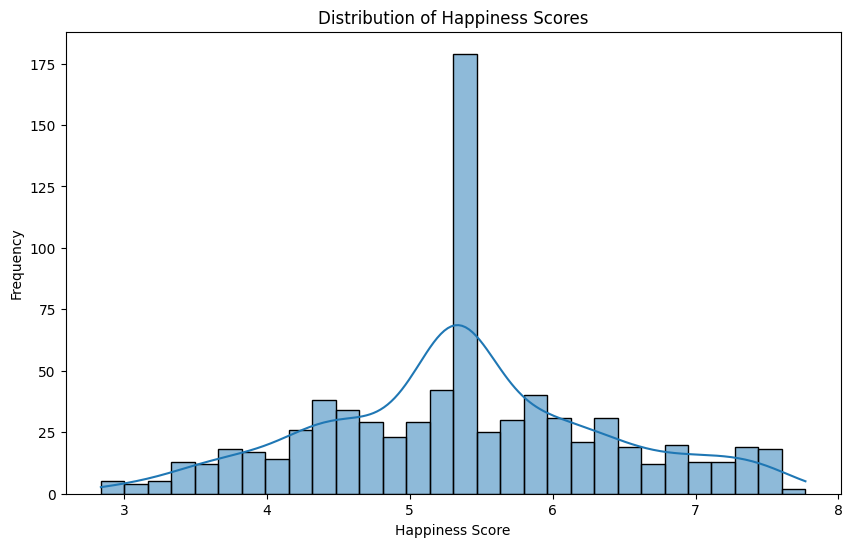

In [32]:
# Distribution of Happiness Scores
plt.figure(figsize=(10,6))
sns.histplot(combined_data['Happiness_Score'], bins=30, kde=True)
plt.title('Distribution of Happiness Scores')
plt.xlabel('Happiness Score')
plt.ylabel('Frequency')
plt.show()

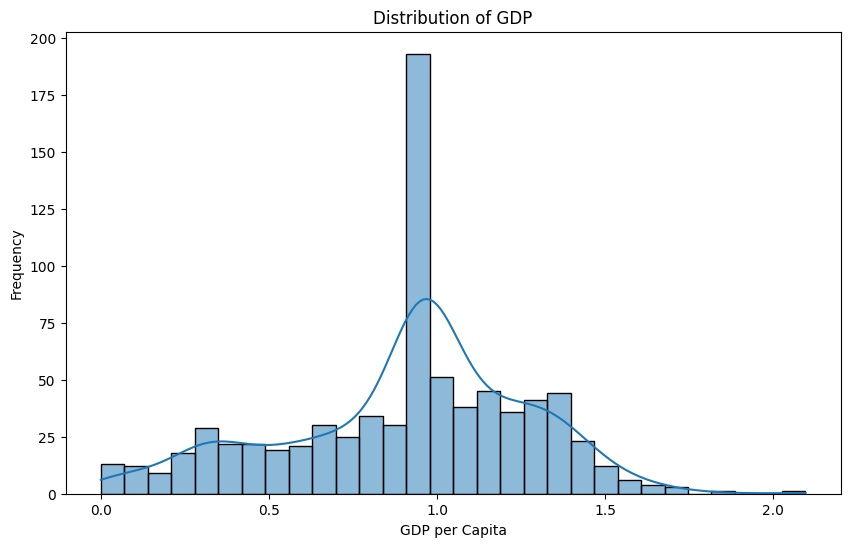

In [33]:
# Distribution of Happiness Scores
plt.figure(figsize=(10,6))
sns.histplot(combined_data['GDP'], bins=30, kde=True)
plt.title('Distribution of GDP')
plt.xlabel('GDP per Capita')
plt.ylabel('Frequency')
plt.show()

Country
Finland        7.1118
Denmark        7.1094
Norway         7.1014
Switzerland    7.0804
Iceland        7.0780
Puerto Rico    7.0390
Netherlands    6.9970
Canada         6.9552
Sweden         6.9302
New Zealand    6.9180
Name: Happiness_Score, dtype: float64


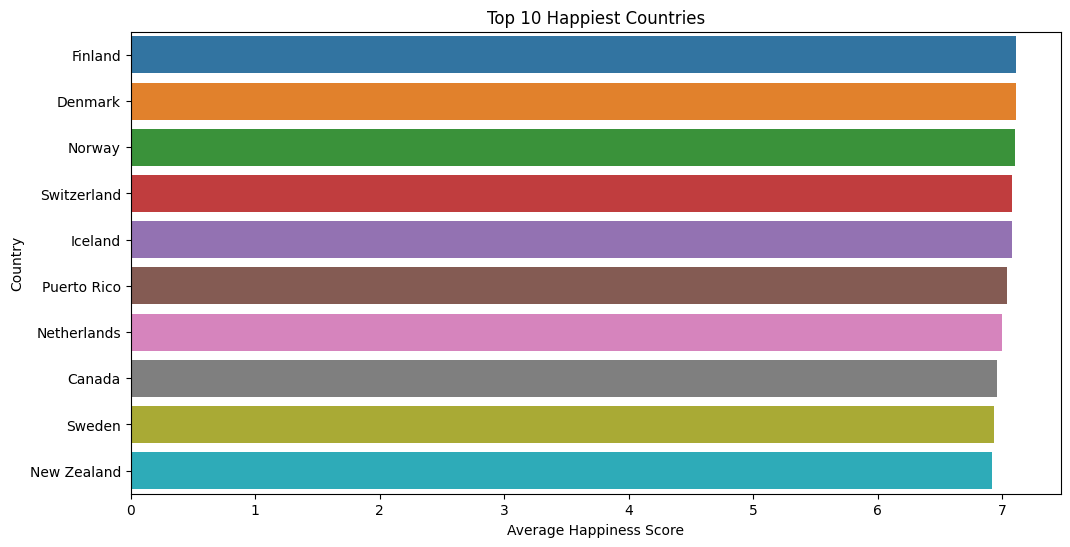

In [34]:
# TOP 10 HAPPIEST COUNTRIES
top_countries = combined_data.groupby("Country")["Happiness_Score"].mean().sort_values(ascending=False).head(10)
print(top_countries)
plt.figure(figsize=(12,6))
sns.barplot(x=top_countries.values,y=top_countries.index)
plt.title("Top 10 Happiest Countries")
plt.xlabel("Average Happiness Score")
plt.show()

## Task 5: Predictive Model or Insight Project 
### Goal:
- Build a simple predictive model or generate meaningful insights from data.
### Examples:
- Simple prediction using regression.
- Classification of data.
- Insight-based recommendation.
### Key Skills:
- Basic machine learning concepts, model understanding.

In [35]:
X = combined_data[['GDP','Social_Support','Life_Expectancy','Freedom','Generosity','Corruption']]
y = combined_data['Happiness_Score']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [36]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.6935867052908966
MAE: 0.41822828784349253


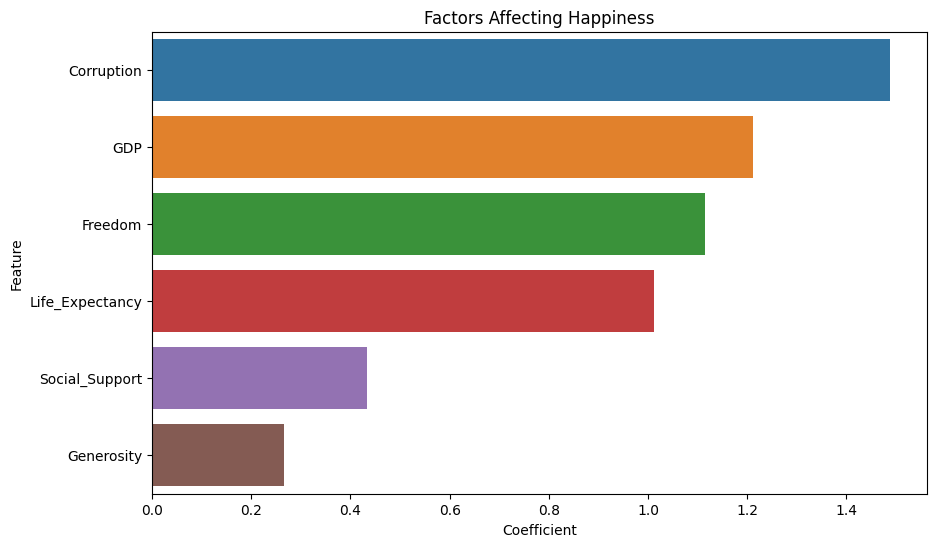

In [37]:
# Feature importance
feature_importance = pd.DataFrame({"Feature": X.columns,"Coefficient": model.coef_})
feature_importance = feature_importance.sort_values(by="Coefficient",ascending=False)
#print(feature_importance)
plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance,x="Coefficient",y="Feature")
plt.title("Factors Affecting Happiness")
plt.show()

In [38]:
model2 = RandomForestRegressor(n_estimators=200, random_state=42)
model2.fit(X_train, y_train) 
y_pred_rf = model2.predict(X_test)
print("Random Forest R2 Score:", r2_score(y_test, y_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

Random Forest R2 Score: 0.7467751520157666
Random Forest MAE: 0.34792216560509587


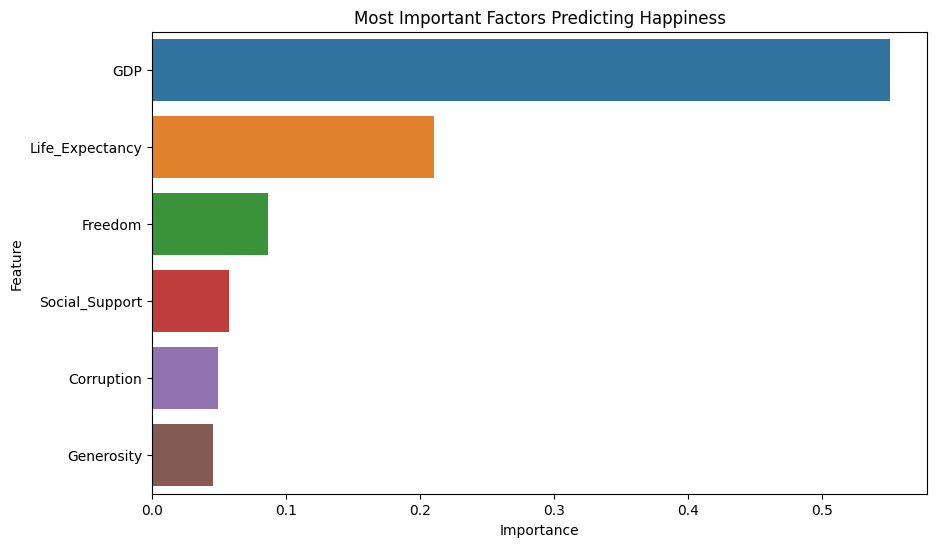

In [39]:
importance_df = pd.DataFrame({'Feature': X.columns,'Importance': model2.feature_importances_})
importance_df = importance_df.sort_values(by='Importance',ascending=False)
#print(importance_df)
# Plot importance
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df,x='Importance',y='Feature')
plt.title("Most Important Factors Predicting Happiness")
plt.show()

In [40]:
results = pd.DataFrame({'Actual': y_test,'Predicted': y_pred})

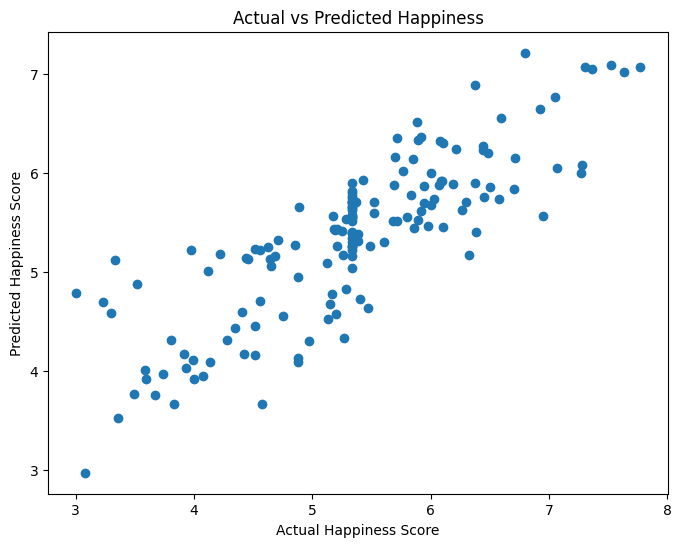

In [41]:
# Scatter plot
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Happiness Score")
plt.ylabel("Predicted Happiness Score")
plt.title("Actual vs Predicted Happiness")
plt.show()

In [42]:
import joblib
joblib.dump(model, "models/happiness_prediction_model.pkl")

['models/happiness_prediction_model.pkl']

In [43]:
combined_data.to_csv("data/cleaned_world_happiness.csv",index=False)